# Лекция 2. Линейные модели регрессии — демонстрации

МНК и нормальные уравнения, устойчивость через SVD, теорема Гаусса–Маркова, гребневая регрессия и Lasso.

> Ноутбук сопровождает лекцию: каждый раздел иллюстрирует кодом соответствующий
> теоретический сюжет. Запускайте ячейки по порядку.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Нормальные уравнения и их слабое место

$$\hat{w}_{\text{OLS}} = (X^T X)^{-1} X^T y.$$

Число обусловленности $\varkappa(X^T X) = \varkappa(X)^2$: если признаки почти линейно зависимы,
прямое обращение теряет точность. SVD решает ту же задачу устойчиво.

In [2]:
# Почти вырожденная матрица: второй признак = первый + крошечный шум
n = 200
x1 = rng.normal(size=n)
x2 = x1 + rng.normal(scale=1e-6, size=n)
X = np.column_stack([np.ones(n), x1, x2])
w_true = np.array([1.0, 2.0, -1.0])
y = X @ w_true + rng.normal(scale=0.1, size=n)

print(f"Число обусловленности X:      {np.linalg.cond(X):.3e}")
print(f"Число обусловленности X^T X:  {np.linalg.cond(X.T @ X):.3e}")

w_normal = np.linalg.inv(X.T @ X) @ X.T @ y          # «в лоб»
w_solve = np.linalg.solve(X.T @ X, X.T @ y)          # через решение системы
w_svd, *_ = np.linalg.lstsq(X, y, rcond=None)        # через SVD

for name, w in [("inv(X^T X)", w_normal), ("solve", w_solve), ("SVD / lstsq", w_svd)]:
    print(f"{name:12s} невязка ||Xw - y|| = {np.linalg.norm(X @ w - y):.6f}")

Число обусловленности X:      1.737e+06
Число обусловленности X^T X:  3.020e+12
inv(X^T X)   невязка ||Xw - y|| = 1.431712
solve        невязка ||Xw - y|| = 1.431712
SVD / lstsq  невязка ||Xw - y|| = 1.431712


Все три дают близкую невязку, но у первого способа сами коэффициенты «пляшут»:
при мультиколлинеарности веса определены плохо, хотя предсказания почти совпадают.
Это ровно та ситуация, в которой нужна регуляризация.

## 2. Теорема Гаусса–Маркова

При условиях $\mathbb{E}\varepsilon = 0$, $\operatorname{Var}\varepsilon = \sigma^2 I$ оценка МНК —
**лучшая линейная несмещённая** (BLUE). Проверим несмещённость экспериментально.

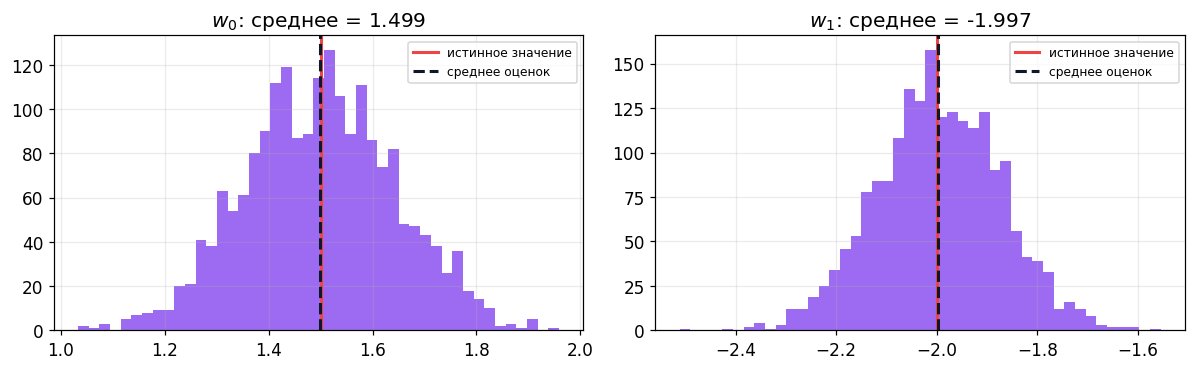

In [3]:
from sklearn.linear_model import LinearRegression

n_exp, n_obs = 2000, 50
w_true_simple = np.array([1.5, -2.0])
estimates = np.zeros((n_exp, 2))

for k in range(n_exp):
    x = rng.uniform(-2, 2, n_obs)
    Xk = np.column_stack([np.ones(n_obs), x])
    yk = Xk @ w_true_simple + rng.normal(0, 1.0, n_obs)
    estimates[k] = np.linalg.lstsq(Xk, yk, rcond=None)[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, j, name in zip(axes, [0, 1], [r"$w_0$", r"$w_1$"]):
    ax.hist(estimates[:, j], bins=45, color="#7c3aed", alpha=0.75)
    ax.axvline(w_true_simple[j], color="#ef4444", lw=2, label="истинное значение")
    ax.axvline(estimates[:, j].mean(), color="#0f172a", ls="--", lw=2, label="среднее оценок")
    ax.set_title(f"{name}: среднее = {estimates[:, j].mean():.3f}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Ridge и Lasso: траектории коэффициентов

$$\hat{w}_{\text{ridge}} = \arg\min_w \|Xw - y\|^2 + \lambda\|w\|_2^2, \qquad
  \hat{w}_{\text{lasso}} = \arg\min_w \|Xw - y\|^2 + \lambda\|w\|_1.$$

Ridge сжимает веса плавно, Lasso обнуляет их полностью — отсюда отбор признаков.

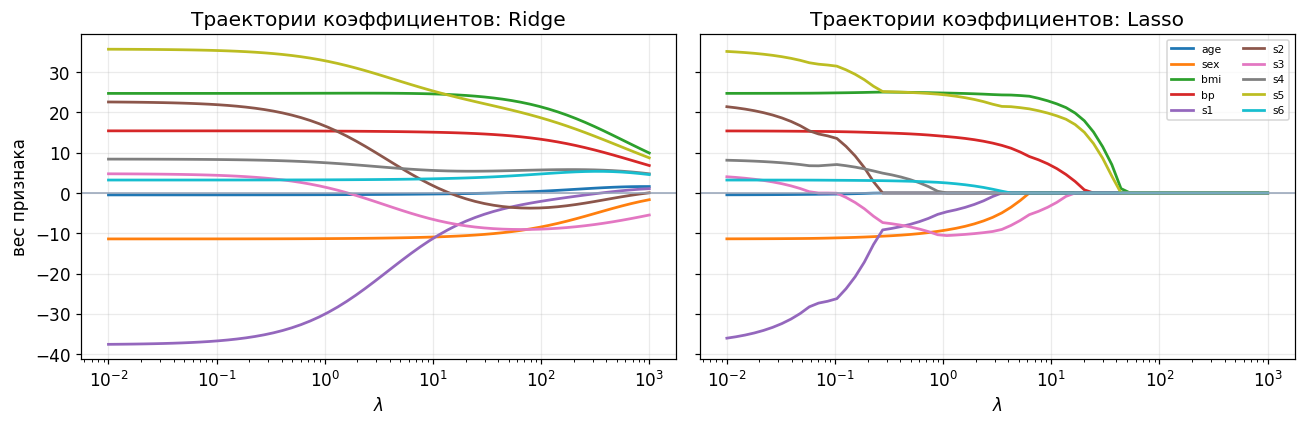

Ненулевых весов Lasso: от 10 до 0 при росте lambda


In [4]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

data = load_diabetes()
Xd = StandardScaler().fit_transform(data.data)
yd = data.target

alphas = np.logspace(-2, 3, 60)
ridge_path = np.array([Ridge(alpha=a).fit(Xd, yd).coef_ for a in alphas])
lasso_path = np.array([Lasso(alpha=a, max_iter=10000).fit(Xd, yd).coef_ for a in alphas])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for j, name in enumerate(data.feature_names):
    ax1.plot(alphas, ridge_path[:, j], lw=1.8)
    ax2.plot(alphas, lasso_path[:, j], lw=1.8, label=name)

for ax, title in [(ax1, "Ridge"), (ax2, "Lasso")]:
    ax.set_xscale("log"); ax.axhline(0, color="#94a3b8", lw=1)
    ax.set_xlabel(r"$\lambda$"); ax.set_title(f"Траектории коэффициентов: {title}")
ax1.set_ylabel("вес признака")
ax2.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

nonzero = (np.abs(lasso_path) > 1e-8).sum(axis=1)
print("Ненулевых весов Lasso: от", nonzero.max(), "до", nonzero.min(), "при росте lambda")

## 4. Почему Lasso зануляет веса

Геометрия: линии уровня MSE — эллипсы, а ограничение $\|w\|_1 \le t$ — ромб с углами на осях.
Эллипс с большой вероятностью касается ромба именно в углу, где одна координата равна нулю.
У шара $\|w\|_2 \le t$ углов нет.

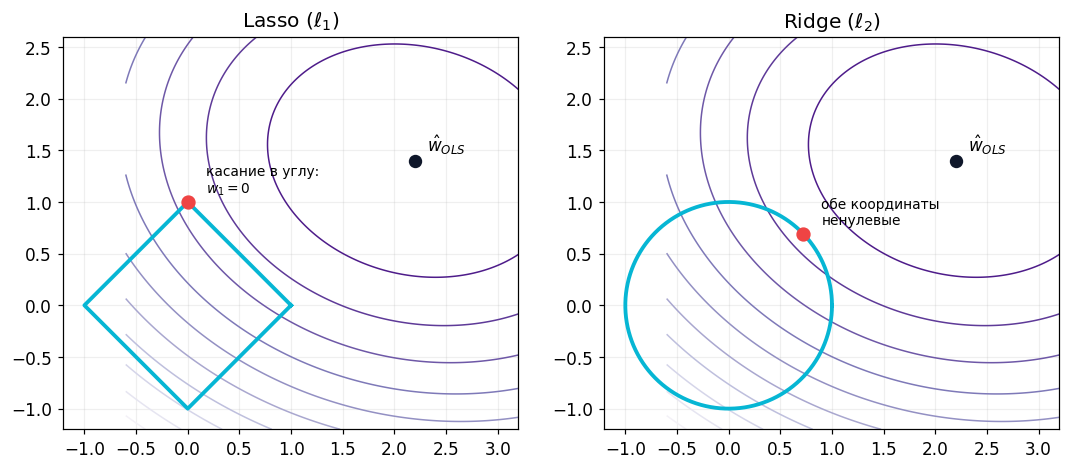

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
theta = np.linspace(0, 2 * np.pi, 400)
w_ols = np.array([2.2, 1.4])

for ax, kind in zip(axes, ["Lasso ($\\ell_1$)", "Ridge ($\\ell_2$)"]):
    # линии уровня квадратичной ошибки вокруг решения МНК
    g1, g2 = np.meshgrid(np.linspace(-0.6, 3.2, 300), np.linspace(-1.2, 2.6, 300))
    q = 1.0 * (g1 - w_ols[0]) ** 2 + 0.35 * (g1 - w_ols[0]) * (g2 - w_ols[1]) + 1.6 * (g2 - w_ols[1]) ** 2
    ax.contour(g1, g2, q, levels=12, cmap="Purples_r", linewidths=1)

    if kind.startswith("Lasso"):
        t = 1.0
        ax.plot([t, 0, -t, 0, t], [0, t, 0, -t, 0], color="#06b6d4", lw=2.5)
        ax.scatter([0], [1.0], color="#ef4444", zorder=5, s=70)
        ax.annotate("касание в углу:\n$w_1 = 0$", (0, 1.0), textcoords="offset points",
                    xytext=(12, 6), fontsize=9)
    else:
        t = 1.0
        ax.plot(t * np.cos(theta), t * np.sin(theta), color="#06b6d4", lw=2.5)
        ax.scatter([0.72], [0.69], color="#ef4444", zorder=5, s=70)
        ax.annotate("обе координаты\nненулевые", (0.72, 0.69), textcoords="offset points",
                    xytext=(12, 6), fontsize=9)

    ax.scatter(*w_ols, color="#0f172a", s=60, zorder=5)
    ax.annotate(r"$\hat{w}_{OLS}$", w_ols, textcoords="offset points", xytext=(8, 6))
    ax.set_title(kind); ax.set_aspect("equal"); ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Подбор λ по кросс-валидации

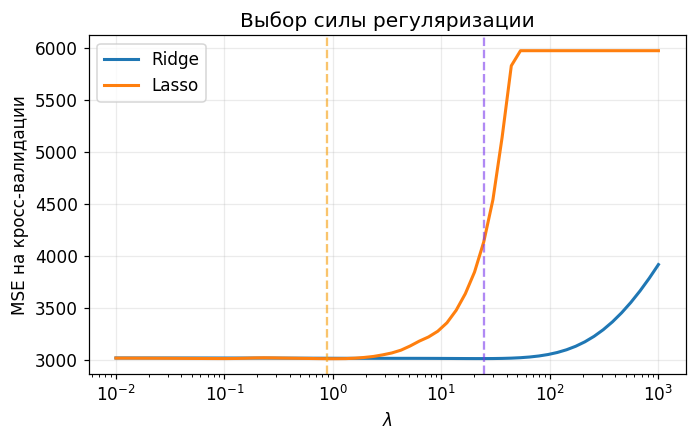

Лучшее lambda для Ridge: 24.538  (MSE 3009.5)
Лучшее lambda для Lasso: 0.890  (MSE 3008.4)


In [6]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(5, shuffle=True, random_state=RANDOM_STATE)
mse_ridge = [-cross_val_score(Ridge(alpha=a), Xd, yd, cv=cv,
                              scoring="neg_mean_squared_error").mean() for a in alphas]
mse_lasso = [-cross_val_score(Lasso(alpha=a, max_iter=10000), Xd, yd, cv=cv,
                              scoring="neg_mean_squared_error").mean() for a in alphas]

plt.semilogx(alphas, mse_ridge, lw=2, label="Ridge")
plt.semilogx(alphas, mse_lasso, lw=2, label="Lasso")
plt.axvline(alphas[int(np.argmin(mse_ridge))], color="#7c3aed", ls="--", alpha=0.6)
plt.axvline(alphas[int(np.argmin(mse_lasso))], color="#f59e0b", ls="--", alpha=0.6)
plt.xlabel(r"$\lambda$"); plt.ylabel("MSE на кросс-валидации")
plt.title("Выбор силы регуляризации")
plt.legend()
plt.show()

print(f"Лучшее lambda для Ridge: {alphas[int(np.argmin(mse_ridge))]:.3f}  (MSE {min(mse_ridge):.1f})")
print(f"Лучшее lambda для Lasso: {alphas[int(np.argmin(mse_lasso))]:.3f}  (MSE {min(mse_lasso):.1f})")